# Lecture 23 - Dimensionality Reduction with Principal Component Analysis (PCA) & Introduction to Artificial Neural Networks (ANNs)

---

# Principal Component Analysis (PCA)

A very common approach (and one of the simplest approaches) to **dimensionality reduction** is **Principal Component Analysis** (or **PCA**). 

* PCA takes data from *sensor coordinates* to *data centric coordinates* using linear transformations.

PCA uses a **linear transformation** to **minimize the redundancy** of the resulting transformed data (by ending up with data that is uncorrelated).
* This means that every transformed dimension is more informative.
* In this approach, the dimensionality of the space is still the same as the original data, but the space of features are now arranged such that they contain the most information.

If we wish to reduce dimensionality of our feature space, we can choose only the features that carry over the most information in the linearly transformed space.
* In other words, PCA will find the underlying **linear manifold** that the data is embedded in.

**PCA finds the directions of maximum variance in high-dimensional data and projects it onto a new subspace with equal or fewer dimensions than the original one**. 

There are a couple of points-of-view on how to find $A$: 

1. Maximum Variance Formulation
2. Minimum-error Formulation

## 1. PCA as Maximum Variance Formulation

Consider the data $X$ comprised on $N$ data samples in a D-dimensional space, so $X$ is a matrix of size $D\times N$.

The **first step** in PCA is to centralize or demean $X$. This will is to guarantee that all features will have the same impact and not weight more only because their range of values is much larger (example, age vs income).

* Without loss of generality, let's assume that we subtracted the mean to the input data, $X$. Now, $X$ has zero mean.

The **second step** is to find the linear transformation $A$ that transforms $X$ to a space where features are:
1. Uncorrelated (preserve all dimensions)
2. reduced (dimensionality reduction)

\begin{align*}Y = AX\end{align*}

where $A$ is a $D\times D$ matrix, $X$ is a $D\times N$ data matrix and therefore $Y$ is also a $D\times N$ transformed data matrix.

The variance of the transformed data $Y$ is given by:

\begin{align*}
R_y &= E[YY^T] \\
&= E[AX(AX)^T] \\
&= E[AXX^TA^T] \\
&= AE[XX^T]A^T \\
&= AR_xA^T
\end{align*}

Note that we are computing the variance along the dimensions of $Y$, therefore, $R_y$ is a $D\times D$ matrix. Similarly, $R_X$ represents the covariance of the data $X$. Covariances matrices are symmetric therefore $R_X=R_X^T$ and $R_Y=R_Y^T$.

Similarly, $R_X$ represents the covariance of the data $X$. 

If we write $A$ in terms of vector elements:

\begin{align*}A = \left[\begin{array}{cc}
a_{11} & a_{12}\\
a_{21} & a_{22}
\end{array}\right]=\left[\begin{array}{c}
\overrightarrow{a_{1}}^T\\
\overrightarrow{a_{2}}^T
\end{array}\right]\end{align*}

Then,

\begin{align*}
R_y &= \left[\begin{array}{c}a_{1}^T\\a_{2}^T\end{array}\right] R_X \left[\begin{array}{cc}a_{1} & a_{2}\end{array}\right] \\
&= \left[\begin{array}{cc} a_1^T R_X a_1 & a_1^T R_X a_2\\ a_2^T R_X a_1 & a_2^T R_X a_2\end{array}\right]
\end{align*}

* If we want to represent the data in a space in which the features are **uncorrelated**, what shape does the covariance matrix have to take?

Diagonal! Why?

* Can we use the eigenvectors of $R_X$ as our linear transformation $A$?

Consider the case where we are trying to project the data $X$ into a 1-dimensional space, so we are trying to find the direction $a_1$ where maximal data variance is preserved:

\begin{align*}
\arg_{a_1} \max a_1^T R_X a_1\end{align*}

We want this solution to be bounded (considering $a_1 = \infty$ would maximize), so we need to constraint the vector to have norm 1

\begin{align*}\Vert a_1\Vert_2^2 = 1 \iff a_1^T a_1 = 1  \iff a_1^T a_1 - 1 = 0\end{align*}

Then, we using Lagrange Optimization:

\begin{align*}\mathcal{L}(a_1, \lambda_1) = a_1^T R_X a_1 - \lambda_1 (a_1^T a_1 - 1)\end{align*}

Solving for $a_1$:

\begin{align*}
&\frac{\partial \mathcal{L}}{\partial a_1} = 0 \iff 2R_X a_1 - 2\lambda_1 a_1 = 0 \iff R_X a_1 = \lambda_1 a_1
\end{align*}

* Does this look familiar?

This is stating that $a_1$ must be an eigenvector of $R_X$!

So coming back to the question "Can we use the eigenvectors of $X$ as our linear transformation $A$?" YES!

* If we left multiply by $a_1^T$ and make use of $a_1^Ta_1 = 1$:

\begin{align*}a_1^T R_X a_1 = \lambda_1\end{align*}

**So the variance will be maximum when we set the project direction $a_1$ equal to the eigenvector having the largest eigenvalue $\lambda_1$**.

* This eigenvector is known as the firt **principal component**.

* As you may anticipate, the linear trasnformation $A$ will the be a matrix whose row entries are **sorted** the eigenvectors (sorted by their correspondent eigenvalue).

\begin{align*}A &= \left[\begin{array}{c}
\overrightarrow{a_{1}}^T\\
\overrightarrow{a_{2}}^T
\end{array}\right]\end{align*}

where $a_1$ and $a_2$ are eigenvectors of $R_X$ with correspondent eigenvalues $\lambda_1$ and $\lambda_2$ with $\lambda_1>\lambda_2$.

## 2. PCA as Minimum-error Formulation

We can also look at PCA as a minimization of mean squared error.

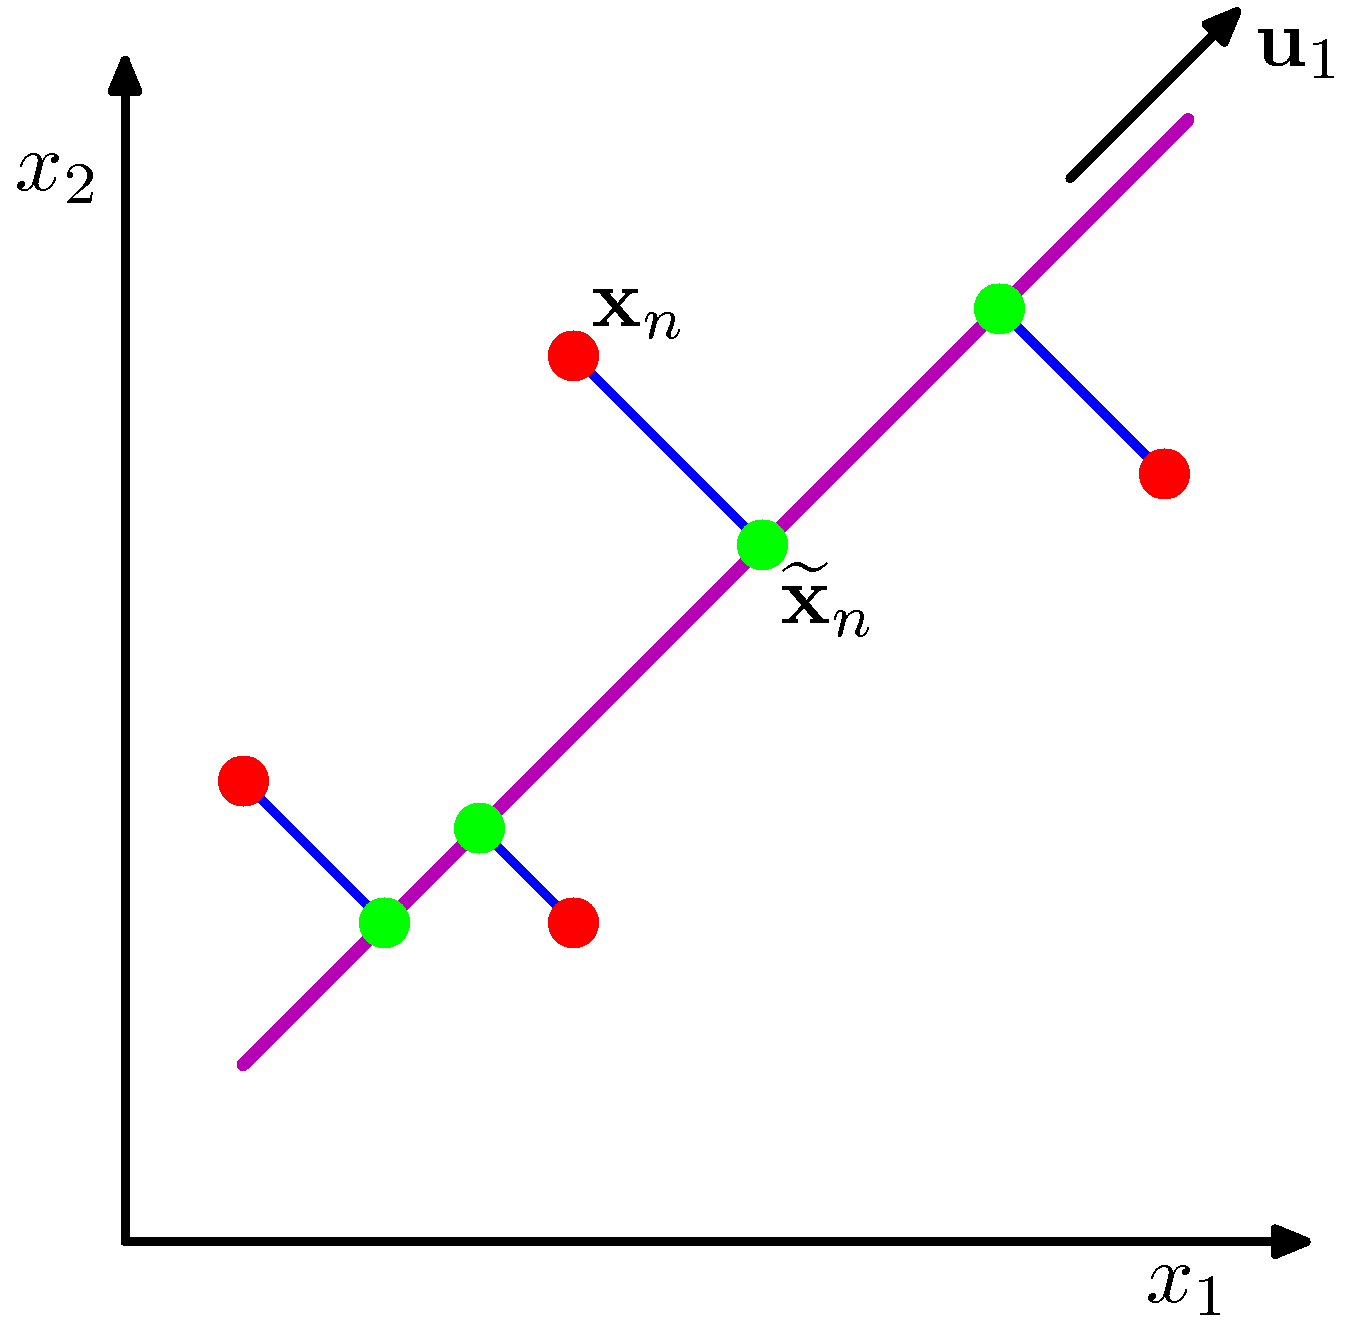

In [1]:
from IPython.display import Image
Image('figures/Figure12.2.png',width=300)
# Source: Bishop textbook

Consider $X$ and a D-dimensional orthogonal basis $\mathbf{u}$:

\begin{align*}\hat{x} = \sum_{i=1}^m y_i a_i\end{align*}

where $m<D$.

\begin{align*}y_j = x^Ta_j \end{align*}

where $A^TA = I$.

We want to minimize the residual error:

\begin{align*}\epsilon = x - \hat{x} = \sum_{i=m+1}^D y_i a_i\end{align*}

* The objective function we will use is the mean square residual:

\begin{align*}
J &= E\left[ \|\epsilon\|^2_2\right]\\
&= E\left[\left( \sum_{i=m+1}^D y_ia_i\right)\left( \sum_{i=m+1}^D y_i a_i\right) \right]\\
&=\sum_{j=m+1}^D E [y_j^2], \text{because }a_i^Ta_j=0, \forall i\neq j \text{ and }a_i^Ta_j=1, \forall i=j\\
&=\sum_{j=m+1}^D E [(a_j^T\mathbf{x})(\mathbf{x}^Ta_j)]\\
&= \sum_{j=m+1}^D a_j^T E[\mathbf{x}\mathbf{x}^T]a_j\\
&= \sum_{j=m+1}^D a_j^T R_x a_j
\end{align*}

Minimize the error and incorporate Lagrange parameters for $A^TA=I$:

\begin{align*}
\frac{\partial J}{\partial a_j} &= 2(R_x a_j - \lambda_j a_j) = 0\\
R_x a_j &= \lambda_j a_j
\end{align*}

So, the sum of the error is the sum of the eigenvalues of the unused eigenvectors.  So, we want to select the eigenvectors with the $m$ largest eigenvalues. 

___

# Pseudo-code for Implementing PCA

Consider the data $X$ with $N$ data points defined in a $D$-dimensional space, that is, $X$ is a $D\times N$ matrix.

(Subtract the mean, $\mu = \frac{1}{N}\sum_{i=1}^N x_i$.)

1. Compute the covariance matrix $R_X$ (by definition, the covariance already subtracts the data's mean). This matrix is of size $D\times D$.

2. Compute eigenvectors and eigenvalues of the matrix $R_X$, and store the sorted eigenvectors ($e_i$) in decreasing eigenvalue ($\lambda_i$) order.

3. Build the modal matrix $\mathbf{U} = \left[\begin{array}{c} \mathbf{e_{1}} &| & \mathbf{e_{2}} &|\dots |& \mathbf{e_{D}}\end{array}\right]$, where all the (unit-length) eigenvectors are stacked in columns, sorted by their respective eigenvalues, i.e., $\lambda_1>\lambda_2>\dots>\lambda_D$.

    * For **uncorrelating the data**, preserve all $D$ eigenvectors. Hence $\mathbf{U}$ is a $D \times D$ matrix.
    * For **dimensionality reduction**, keep the top $M$ eigenvectors with the largest eigenvalues. Hence $\mathbf{U}$ is a $D \times M$ matrix.

4. Apply the linear transformation: $\mathbf{y} = \mathbf{U}^T \mathbf{X}$. Here $\mathbf{y}$ is a matrix of size $M \times N$, where $M\leq D$.

Note that the formal definition of covariance already accounts for demeaning the data.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import scipy.stats as stats
import pandas as pd

In [ ]:
# Helper functions

def plotvec(*argv):
    colors=['k','b','r','g','c','m']
    xmin=0
    xmax=-1000000
    ymin=0
    ymax=-1000000
    origin=[0,0]
#     plt.figure()
    for e in enumerate(argv):
        i=e[0]
        arg=e[1]
        plt.quiver(*origin,*arg,angles='xy',scale_units='xy',scale=1,
                   color=colors[i%len(colors)])
        xmin=min(xmin,arg[0])
        xmax=max(xmax,arg[0])
        ymin=min(ymin,arg[1])
        ymax=max(ymax,arg[1])
#     plt.xlim(min(-1, xmin-1), max(1,xmax+1))
#     plt.ylim(min(-1,ymin-1),max(1,ymax+1))

def plot_contours(K,X=None, R=None):
    '''This function plots the contours of a Bivariate Gaussian RV with
    mean [0,0] and covariance K'''
    
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    xm, ym = np.meshgrid(x, np.flip(y))
    if X is None:
        X = np.dstack([xm,ym])
    if R is not None:
        X = X@R
    
    G = stats.multivariate_normal.pdf(X,mean=[0,0],cov=K)
    
    plt.figure(figsize=(6,6))
    plt.contour(xm,ym,G, extent=[-3,3,-3,3],cmap='viridis');
    
def makerot(theta):
    '''This function creates a 2x2 rotation 
    matrix for a given angle (theta) in degrees'''
    
    theta=np.radians(theta)
    
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    
    return R

In [ ]:
data = stats.multivariate_normal([0,0],[[1,0.8],[0.8,2]]).rvs(size=100)

data.shape

In [ ]:
plt.scatter(data[:,0],data[:,1]);

In [ ]:
K = np.cov(data.T)

K

In [ ]:
plot_contours(K)
plt.scatter(data[:,0],data[:,1]);

In [ ]:
L, V = np.linalg.eigh(K)

L, V

In [ ]:
L=L[::-1]

V=V[:,::-1]

In [ ]:
plot_contours(K)
plt.scatter(data[:,0],data[:,1])
plotvec(V[:,0], V[:,1])
plt.legend(['Data','Eigenvector 1', 'Eigenvector 2']);

In [ ]:
rotated = V.T@data.T

rotated.shape

In [ ]:
K2 = np.cov(rotated)

np.round(K2,7)

In [ ]:
plot_contours(K2)
plt.scatter(rotated[0,:],rotated[1,:])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2');

In [ ]:
e1=np.array([[1],[0]])

angle = np.degrees(np.arccos((e1.T@V[:,0])/(np.linalg.norm(e1)*np.linalg.norm(V[:,0]))))[0]

angle

In [ ]:
rotated2 = makerot(-angle)@data.T

In [ ]:
K3 = np.cov(rotated2)

np.round(K3,7)

In [ ]:
plot_contours(K3)
plt.scatter(rotated2[0,:],rotated2[1,:])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2');

---

## Wine Dataset

In [ ]:
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                   'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium',
                   'Total phenols', 'Flavanoids',
                   'Nonflavanoid phenols',
                   'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines',
                   'Proline']

df_wine

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target Labels
t = df_wine['Class label'].values

# Feature Matrix
X = df_wine.drop(['Class label'], axis=1).values
print(X.shape)

# Stratified partition of the data into training/test sets
X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    test_size=0.3, 
                                                    stratify=t,
                                                    random_state=0)
# Scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Covariance dataset
cov_train = np.cov(X_train.T)

plt.figure(figsize=(8,5))
plt.imshow(cov_train)
plt.colorbar()
plt.xticks(range(13),df_wine.columns[1:],rotation=90)
plt.yticks(range(13),df_wine.columns[1:]);

Building a function to implement PCA from scratch:

In [ ]:
def myPCA(X, m, display=1):
    '''This function implements PCA. The data matrix X is DxN matrix, 
    where D is the dimension and N the number of points'''
    
    N, D = X.shape
    
    # Covariance of the input data X
    cov_mat = #
    
    # Find eigenvectors and eigenvalues 
    eigen_vals, eigen_vecs = #
    # np.linalg.eigh sorts vectors in increasing order of eigenvalues
    
    # Sort eigenvectors by magnitude of eigenvalues
    L = #
    U = #

    # Linear transformation
    A = #
    # Eigenvectors stored in columns
    
    #compute explained variance and plot
    sum_eigs = np.sum(L) # summing all eigenvalues
    explained_var = np.array([(i/sum_eigs) for i in L]) # explained variance for each PC
    cumulative_explained_var = np.cumsum(explained_var) # cumulative explained variance

    # Visualizing explained variance for each PC and cumulative
    if display: 
        plt.bar(range(1,D+1), explained_var, alpha=0.5, align='center', label='individual explained variance')
        plt.step(range(1,D+1), cumulative_explained_var, alpha=0.5, where='mid', label='cumulative explained variance')
        plt.ylabel('Explained variance ratio')
        plt.xlabel('Principal components')
        plt.legend(loc='best');
    
    
    return A, explained_var

In [ ]:
A, explained_var = myPCA(X_train, 13)

A.shape

In [ ]:
explained_var

In [ ]:
np.where(np.cumsum(explained_var)>=0.9)

In [ ]:
np.cumsum(explained_var)[7]

# So, we need at least 8 eigenvectors to explain at least 90% of the variance

The resulting plot indicates that the first principal component alone accounts for 40 percent of the variance. Also, we can see that the first two principal components combined explain almost 60 percent of the variance in the data.

Although the explained variance plot reminds us of the feature importance, we shall remind ourselves that PCA is an unsupervised method, which means that information about the class labels is ignored.

In [ ]:
X_train_pca = (A@X_train.T).T

print(X_train.shape, X_train_pca.shape)

In [ ]:
# Check
cov_mat = np.cov(X_train_pca.T)

plt.figure(figsize=(8,5))
plt.imshow(cov_mat)
plt.colorbar();

## PCA with ```scikit-learn```

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# PCA?

In [ ]:
pca = PCA(n_components=13)
pca

In [ ]:
pca.fit(X_train) # input expects a matrix of size NxD

In [ ]:
pca.explained_variance_ratio_

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

In [ ]:
# The matrix A = U.T is 

pca.components_.shape

In [ ]:
plt.step(range(1,14),np.cumsum(pca.explained_variance_ratio_),c='r')
plt.bar(range(1,14),pca.explained_variance_ratio_, alpha=0.5)
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components');

In [ ]:
y_train_pca = pca.transform(X_train)

y_train_pca.shape

In [ ]:
cov_mat = np.cov(y_train_pca.T)

plt.figure(figsize=(8,5))
plt.imshow(cov_mat)
plt.colorbar()
plt.yticks(range(13),['PC'+str(i) for i in range(1,14)])
plt.xticks(range(13),['PC'+str(i) for i in range(1,14)], rotation=90);

In [ ]:
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']

for l, c, m in zip(np.unique(t_train), colors, markers):
    plt.scatter(y_train_pca[t_train==l, 0], y_train_pca[t_train==l, 1],c=c, label=l, marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.show()

The training data is used to find the new features (eigenvectors). We can then represent the test set in this new feature space:

In [ ]:
y_test_pca = pca.transform(X_test)

y_test_pca.shape

---

# Applications: Image Compression (Eigenfaces)

In [ ]:
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(return_X_y=False)

print(faces.DESCR)

In [ ]:
X = faces.data # data matrix

t = faces.target # target label

X.shape, t.shape # 400 images, each of size 64x64=4096 pixels

In [ ]:
fig = plt.figure(figsize=(10,10))
for i in range(40):
    fig.add_subplot(7,6,i+1)
    idx = np.random.choice(np.where(t==i)[0])
    plt.imshow(X[idx,:].reshape(64,64), cmap='gray')
    plt.axis('off')

In [ ]:
np.unique(t, return_counts=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    test_size=0.2,
                                                    stratify=t,
                                                    random_state=0)

X_train.shape, t_train.shape, X_test.shape, t_test.shape

In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([('scaler', StandardScaler()),
                ('pca', PCA(n_components=320))])

pipe.fit(X_train, t_train)

The maximum number of dimensions using PCA is $\min(D, N)$.

In [ ]:
# pipe.named_steps['pca'].explained_variance_ratio_

In [ ]:
plt.plot(100*np.cumsum(pipe.named_steps['pca'].explained_variance_ratio_), '-o')
plt.xlabel('Principal Components',size=15)
plt.ylabel('Cumulative Explained Variance, in %', size=15);

In [ ]:
np.where(np.cumsum(pipe.named_steps['pca'].explained_variance_ratio_)>=0.9)

In [ ]:
np.cumsum(pipe.named_steps['pca'].explained_variance_ratio_)[61]

In order to explain 90% of the variance in the data, we need to preserve 63 principal components.

Let's project to 2-D so we can plot it:

In [ ]:
ypca = pipe.transform(X_train)
ypca.shape

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(ypca[:,0], ypca[:,1], c=t_train, cmap=plt.cm.gist_rainbow)
plt.xlabel('Principal Component 1', size=15)
plt.ylabel('Principal Component 2', size=15)
plt.title('Training Set')
plt.colorbar();

Not that the 40 classes are overlapping in the linear projection space. This is because PCA is **unsupervised**, it does use the class labels *anywhere* in finding the matrix for linear projection.

To apply this transformation in the test set, simply multiply the resultant modal matrix with the scaled test set:

In [ ]:
# Transform the test set using the linear transformation found with the training data
ypca_test = pipe.transform(X_test)

ypca_test.shape

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(ypca_test[:,0], ypca_test[:,1], c=t_test, cmap=plt.cm.gist_rainbow)
plt.xlabel('Principal Component 1', size=15)
plt.ylabel('Principal Component 2', size=15)
plt.title('Test Set')
plt.colorbar();

You can access the linear transformation $\mathbf{A} = \mathbf{U}^T$ using the method ```components_```:

In [ ]:
A = pipe.named_steps['pca'].components_

A.shape

Note that the eigenvectors are described in the original space, that is, they are 4096-dimensional!

Since we are working with images, we can reshape them back to a $64 \times 64$ image and see what are the regions in the image with maximum explained variance! This is called the **eigenfaces**.

In [ ]:
n_components = 16

fig=plt.figure(figsize=(10,10))
for i in range(n_components):
    fig.add_subplot(4,4,i+1)
    plt.imshow(abs(A[i,:].reshape(64,64)),cmap='gray')
    plt.axis('off')

The eigenvectors are describing the pixels in the 64x64 image that explain the most variance. The more eigenvectors are kept, the better the reconstructed image is.

Since the projection is given by:

$$\mathbf{Y} = \mathbf{A}\mathbf{X}$$

In order to recover $\mathbf{X}$, we need to left-multiply by the pseudo-inverse of $\mathbf{A}$:

$$\hat{\mathbf{X}} = \mathbf{A}^\dagger\mathbf{Y}$$

Let's reconstruct the images in the dataset using the eigenvectors that explain 90% of the variance.

In [ ]:
N_eigenvectors = 320

# Designing and training dimensionality reduction model
pipe = Pipeline([('scaler', StandardScaler()),
                ('pca', PCA(n_components=N_eigenvectors))])
pipe.fit(X_train, t_train)

# Transforming data
ypca = pipe.transform(X_train)

# Reconstructing data
# This includes pseudo_inv(A)*Y and inverse transform for the StandardScaler transform
X_reconstructed = pipe.inverse_transform(ypca)

# Select 5 random images from training
N = 5
fig = plt.figure(figsize=(15,5))
idx = np.random.choice(range(X_reconstructed.shape[0]),replace=False,size=N)
j=1
for i in range(N):
    fig.add_subplot(2,N,j)
    plt.imshow(X_train[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Original Image');

    fig.add_subplot(2,N,j+N)
    plt.imshow(X_reconstructed[idx[i],:].reshape(64,64), cmap='gray')
    plt.axis('off')
    plt.title('Reconstructed Image');
    j+=1

---
---
---

# Introduction to Artificial Neural Networks (ANNs)

A **Multi-Layer Perceptron (MLP)** is a class of feed-forward artificial neural network (ANN). An MLP is composed of one **input layer**, one or more layers of TLUs, called **hidden layers**, and one final layer of TLUs called the **output layer**.  Except for the input nodes, each node is a neuron that uses an activation function (either linear or non-linear). 

* The layers close to the input layer are usually called the lower layers, and the ones close to the outputs are usually called the upper layers.
* Every layer except the output layer includes a bias neuron and is fully connected to the next layer.

Its multiple layers and non-linear activation distinguish MLP from a linear perceptron. It can distinguish data that is not linearly separable.

When an Artificial Neural Network (ANN) contains a deep stack of hidden layers, it is called a **deep neural network (DNN)**. The field of Deep Learning studies DNNs, and more generally models containing deep stacks of computations. 

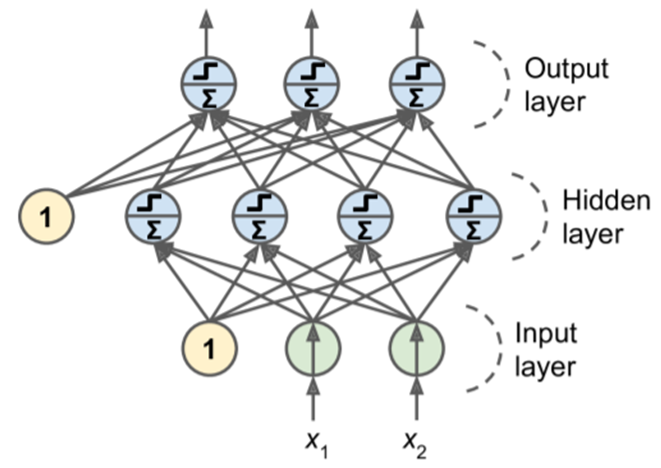

In [2]:
Image('figures/MLPs.png',width=400)
#Source: Aurélien Géron, "Hands-on machine learning with scikit-learn, keras and tensorflow"

In MLPs, each neuron's output can be subject to different activation functions. The choice of the activation function is in itself a *hyperparameter*.

* Which activation function would you use if you desired labels are $\{1,2,3,4,\dots,8,9\}$? 

* *What each of the layers do?*
    * The first hidden layer draws boundaries
    * The second hidden layer combines the boundaries
    * The third and further layers can generate arbitrarily complex shapes

## Types of Activation Functions

In artificial neural networks (ANN), the *activation function* of a neuron defines the output of that neuron given an input or set of inputs.

There are many activation functions, the most common are:

1. **Heaviside Step:**
\begin{align*}
\phi(x) = \begin{cases}1, & x >0 \\ 0, & x\leq 0\end{cases}
\end{align*}

2. **Linear:**
\begin{align*}
\phi(x) = x
\end{align*}

3. **Sigmoid:**
\begin{align*}
\phi(x) = \frac{1}{1+e^{-x}}
\end{align*}

4. **Hyperbolic Tangent (tanh):**
\begin{align*}
\phi(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
\end{align*}

5. **Rectified Linear Unit (ReLU):**
\begin{align*}
\phi(x) = \begin{cases} x, & x> 0 \\ 0, & x \leq 0\end{cases}
\end{align*}

6. **Leaky ReLu:**
\begin{align*}
\phi(x) = \begin{cases} x, & x> 0 \\ 0.01x, & x \leq 0\end{cases}
\end{align*}

7. **Exponential Linear Unit (ELU):**
\begin{align*}
\phi(x) = \begin{cases} x, & x> 0 \\ \alpha (e^x -1), & x \leq 0\end{cases}
\end{align*}

where $\alpha=1.67326$.

8. **Scaled Exponential Linear Unit (SELU):**
\begin{align*}
\phi(x) = \lambda\begin{cases} x, & x> 0 \\ \alpha (e^x -1), & x \leq 0\end{cases}
\end{align*}

where $\alpha=1.67326$ and $\lambda=1.0507$.

9. **Softplus:**
\begin{align*}
\phi(x) = \ln(1+e^x)
\end{align*}

There are many many [other functions](https://en.wikipedia.org/wiki/Activation_function) but these are the most popular.

In [ ]:
def activation_functions(x, alpha=1.67326, lam=1.0507):
    
    linear   = x
    sigmoid  = 1/(1+np.exp(-x))
    tanh     = (np.exp(x)-np.exp(-x))/(np.exp(x)+np.exp(-x))
    softplus = np.log(1+np.exp(x))
    
    relu = x.copy()
    relu[x<=0] = 0
    
    leaky_relu = x.copy()
    leaky_relu[x<=0]=0.01*x[x<=0]
    
    elu = x.copy()
    elu[x<=0] = alpha*(np.exp(x[x<=0])-1)
    
    selu = 1.0507*x.copy()
    selu[x<=0] = lam*alpha*(np.exp(x[x<=0])-1)
        
    functions = np.vstack((linear, sigmoid, tanh, softplus, relu, leaky_relu, elu, selu)).T
    names = ['Linear', 'Sigmoid','Tanh','Softplus','ReLU','Leaky ReLU','ELU','SELU']
    
    return functions, names

In [ ]:
x = np.linspace(-5,5,100)
functions, names = activation_functions(x)

plt.figure(figsize=(15,15))
for i in range(8):
    plt.subplot(4,4,i+1)
    plt.plot(x, functions[:,i], label=names[i])
    plt.legend();

---

# Regression and Classification MLPs

Since the Perceptron algorithm was published in 1957, many developments have been made in the design of complex networks. 

As mentioned above, an MLP is composed of one input layer, one or more layers of TLUs, called hidden layers, and one final layer of TLUs called the output layer. The layers close to the input layer are usually called the lower layers, and the ones close to the outputs are usually called the upper layers. Every layer except the output layer includes a bias neuron and is fully connected to the next layer.

The connections between neurons are called **weight connections**, or simply weights. And they represent the strength of connection. The larger the coefficient, in the absolute sense, the more importance that input neuron will have in the neuron it is connected to.

During training, our goal is to find the best values for the weights such the output predicts the desired target value. 

### Regression MLPs

MLPs can be used for regression tasks. 

* If you want to **predict a single value**, say, for example, the price of a house given many of its features, then you **just need a single output neuron**: its output is the predicted value. 

* For **multivariate regression**, say, to predict multiple values at once, you **need one output neuron per output dimension**. 

* Consider another example, to locate the center of an object on an image, you need to predict 2D coordinates, so you need two output neurons. If you also want to place a bounding box around the object, then you need two more numbers: the width and the height of the object. So, you end up with 4 output neurons.

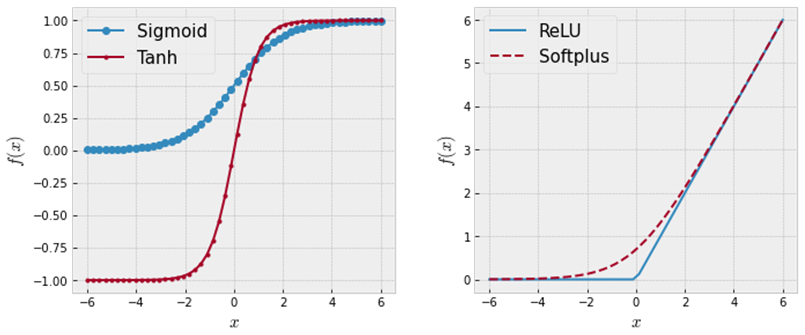

In [3]:
Image('figures/activation_functions.png',width=700)
#Source: Aurélien Géron, "Hands-on machine learning with scikit-learn, keras and tensorflow"

In general, when building an MLP for regression, you do not want to use any **activation function** for the output neurons, so they are free to output any range of values. 

However, if you want to guarantee that the output will always be positive, then you can use the **ReLU activation function**, or the **softplus activation function** in the output layer. 

Finally, if you want to guarantee that the predictions will fall within a given range of values, then you can use the **sigmoid** function or the **hyperbolic tangent** and scale the labels to the appropriate range: 0 to 1 for the logistic function, or –1 to 1 for the hyperbolic tangent.

The loss function to use during training is typically the mean squared error, but if you have a lot of outliers in the training set, you may prefer to use the mean absolute error instead. Alternatively, you can use the Huber loss, which is a combination of both.

### Hyperparameter for Regression MLPs

The hyperparameters represent the set of controllable factors during the design of the MLP architecture. Here is an example of the hyperparameter choices for training an MLP for a regression task.

|Hyperparameter| Typical Value|
| --| --| 
| # input neurons  | One per input feature (e.g., 28x28 =784 for MNIST)  |
|  # hidden layer |  Depends on the problem. Typically, 1 to 5. |
|  # neurons per hidden layer |  Depends on the problem. Typically, 10 to 100. |
| # output neurons  |  1 per prediction dimension |
|  Hidden activation function |  ReLU |
|  Output activation function |  None or ReLU/Softplus (if positive outputs) or Logistic/Tanh (if bounded outputs) |
| Loss function  |  MSE or MAE/Huber (if outliers) |

### Classification MLPs

MLPs, and artificial neural networks in general, can perform both regression and classification tasks.

For a **binary classification problem**, you just need a **single output neuron using the sigmoid activation function**: the output will be a number between 0 and 1, which you can interpret as the estimated probability of the positive class. Obviously, the estimated probability of the negative class is equal to one minus that number.

MLPs can also easily handle **multilabel binary classification tasks**. For example, you could have an email classification system that predicts whether each incoming email is non-spam or spam, and simultaneously predicts whether it is an urgent or non-urgent email. In this case, you would need two output neurons, both using the sigmoid activation function: the first would output the probability that the email is spam and the second would output the probability that it is urgent. More generally, you would dedicate one output neuron for each positive class. Note that the output probabilities do not necessarily add up to one. This lets the model output any combination of labels: you can have non-urgent ham, urgent ham, non-urgent spam, and perhaps even urgent spam (although that would probably be an error).

If each instance can belong only to a single class, out of 3 or more possible classes (for example, classes 0 through 9 for digit image classification), then you need to have one output neuron per class, and you should use the softmax activation function for the whole output layer. The softmax function will ensure that all the estimated probabilities are between 0 and 1 and that they add up to one (which is required if the classes are exclusive). This is called multiclass classification. 

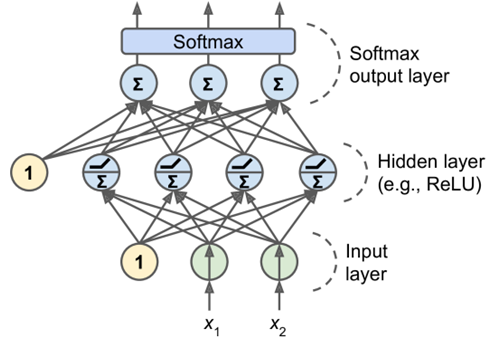

In [4]:
Image('figures/classification_MLPs.png',width=400)
#Source: Aurélien Géron, "Hands-on machine learning with scikit-learn, keras and tensorflow"

| Hyperparameter | Binary Classification | Multilabel binary classification | Multiclass classification|
| --| --| --| --|
| Input and hidden layers | Same as regression | Same as regression | Same as regression|
| # output neurons | 1 | 1 per label | 1 per class|
|Output layer activation | Sigmoid | Sigmoid | Softmax |
| Loss function | Cross-Entropy | Cross-Entropy | Cross-Entropy |

---

# Universal Approximation Theorem

"The *Universal Approximation Theorem* states that a feed-forward network with a single hidden layer containing a finite number of neurons can approximate continuous functions on compact subsets of $\mathbb{R}^N$, under mild assumptions on the activation function. The theorem thus states that simple neural networks can represent a wide variety of interesting functions when given appropriate parameters; however, it does not touch upon the algorithmic learnability of those parameters."

Let $\phi(\cdot)$ be a non-constant, bounded and monotonic-increasing continuous function. Let $I_{m_0}$ denote the $m_0$-dimensional unit hypercube $[0, 1]^{m_0}$. The space of continuous functions on $I_{m_0}$ is denoted by $C(I_{m_0})$.  Then, given any function $f \ni C(I_{m_0})$ and $\epsilon > 0$, there exists an integer $m_1$ and sets of real constants $\alpha_i, \beta_i,$ and $w_{ij}$, where $i = 1, \ldots, m_1$ and $j = 1, \ldots, m_0$ such that we may define

\begin{align*}
F(x_1, \ldots, x_{m_0}) = \sum_{i=1}^{m_1} \alpha_i \phi\left( \sum_{j=1}^{m_0} w_{ij}x_j + b_i\right)
\end{align*}

as an approximation realization of the function $f(\cdot)$, that is, 

\begin{align*}
\left| F(x_1, \ldots, x_{m_0}) - f(x_1, \ldots, x_{m_0}) \right| < \epsilon
\end{align*}

for all $x_1, x_2, \ldots, x_{m_0}$ that like in the input space.

Essentially, the Universal Approximation Theorem states that a single hidden layer is sufficient for a multilayer perceptron to compute a uniform $\epsilon$ approximation to a given training set - provided you have the *right* number of neurons and the *right* activation function. 

* However, this does not say that a single hidden layer is optimal with regards to learning time, generalization, etc.)

* In other words, a **feed-forward MLP with one hidden layer can approximate arbitrarily closely any continuous function**. (Wow!)

___